# TransCODE All-Tool Comparison: Annotated vs Non-Annotated ORFs

Compares annotated (CDS) and non-annotated (non_CDS) outputs for all five tools
(PRICE, RiboTIE, ORFQuant, iRibo, RibORF2) using `source_feature_class` from
the rebuilt translon DB.

All counts are **unique genomic features** (`feature_key` =
`chrom:start-end:strand:block_sizes:block_starts`).  The same genomic ORF
structure appearing on multiple isoforms or in multiple samples is counted once
per tool, not once per occurrence.

In [13]:
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is None:
        matplotlib.use('Agg')
    else:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── DB path ────────────────────────────────────────────────────────────────────
DB = Path("/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite")
# Local fallback:
# DB = Path("/Users/jackt/translon_db/translon_db_v2/translon_db/translon_db/translons.sqlite")
if not DB.exists():
    raise FileNotFoundError(f"DB not found: {DB}  — update DB path above")
con = sqlite3.connect(DB)
print(f"Opened: {DB}")

# ── visual constants ────────────────────────────────────────────────────────────
TOOL_ORDER  = ["PRICE", "RiboTIE", "ORFQuant", "iRibo", "RibORF2"]
CLS_ORDER   = ["cds", "non_cds"]
TOOL_COLORS = {
    "PRICE":    "#f58518",
    "RiboTIE":  "#54a24b",
    "ORFQuant": "#4c78a8",
    "iRibo":    "#e45756",
    "RibORF2":  "#9467bd",
}
CLS_COLORS = {"cds": "#2ca02c", "non_cds": "#1f77b4"}
CLS_LABELS = {"cds": "Annotated CDS", "non_cds": "Novel / non-CDS"}

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 120)

Opened: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite


## DB overview

In [14]:
manifest = pd.read_sql(
    "SELECT detected_tool, parser_name, parser_status, COUNT(*) AS files, SUM(translons) AS translons "
    "FROM parser_manifest GROUP BY detected_tool, parser_name, parser_status "
    "ORDER BY detected_tool, parser_name",
    con,
)
display(manifest)

,detected_tool,parser_name,parser_status,files,translons
0,ORFQuant,orfquant_bed_exon,ok,50,567830
1,PRICE,bed12,ok,50,326824
2,RibORF2,bed12,ok,25,4130518
3,RiboTIE,ribotie_gtf,ok,72,833845
4,iRibo,iribo_gff,ok,50,470443


In [15]:
# Raw row counts (includes multi-sample / multi-isoform duplicates — informational only)
cls_breakdown = pd.read_sql(
    "SELECT source_tool, source_feature_class, COUNT(*) AS raw_rows, "
    "COUNT(DISTINCT feature_key) AS unique_features "
    "FROM translons GROUP BY source_tool, source_feature_class ORDER BY source_tool, source_feature_class",
    con,
)
display(cls_breakdown)

,source_tool,source_feature_class,raw_rows,unique_features
0,ORFQuant,cds,337902,35265
1,ORFQuant,non_cds,229928,74374
2,PRICE,cds,163764,67099
3,PRICE,non_cds,163060,84070
4,RibORF2,cds,2512848,94989
5,RibORF2,non_cds,1617670,101070
6,RiboTIE,cds,588725,42631
7,RiboTIE,non_cds,245120,52986
8,iRibo,cds,304773,16681
9,iRibo,non_cds,165670,35347


In [16]:
recall = pd.read_sql("SELECT * FROM cds_recall_by_tool ORDER BY source_tool", con)
display(recall)

,source_tool,reference_cds,exact_cds_recalled,exact_cds_recall_pct
0,ANY,94893,559,0.589085
1,ORFQuant,94893,2,0.002108
2,PRICE,94893,0,0.000000
3,RibORF2,94893,546,0.575385
4,RiboTIE,94893,12,0.012646
5,iRibo,94893,0,0.000000


## Core aggregations (unique genomic features)

Two queries underpin all plots:

- **`totals`** — unique `feature_key` values per tool × class (each genomic ORF structure counted once regardless of how many samples or isoforms it appears on)
- **`per_sample`** — unique `feature_key` values per tool × sample × class (how many distinct genomic ORFs each individual sample contributes)

In [17]:
BASE_FILTER = """
    qc_status = 'pass'
    AND sample_id NOT GLOB '*_fastq'
    AND source_feature_class IN ('cds', 'non_cds')
"""

# Unique genomic features per tool × class
totals = pd.read_sql(f"""
    SELECT source_tool, source_feature_class AS cls,
           COUNT(DISTINCT feature_key) AS n
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, source_feature_class
""", con).pivot_table(
    index="source_tool", columns="cls", values="n", fill_value=0
).reindex(index=TOOL_ORDER, columns=CLS_ORDER, fill_value=0)

print("Unique genomic features per tool:")
print(totals)

# Unique genomic features per tool × sample × class
per_sample = pd.read_sql(f"""
    SELECT source_tool, sample_id, source_feature_class AS cls,
           COUNT(DISTINCT feature_key) AS n
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, sample_id, source_feature_class
""", con)

# Start codon profile — one count per unique (tool, cls, feature_key)
sc_counts = pd.read_sql(f"""
    SELECT source_tool, source_feature_class AS cls, start_codon_class,
           COUNT(DISTINCT feature_key) AS n
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, source_feature_class, start_codon_class
""", con)

print(f"\nper_sample rows: {len(per_sample):,}")

Unique genomic features per tool:
cls              cds  non_cds
source_tool                  
PRICE        67099.0  84070.0
RiboTIE      42186.0  52451.0
ORFQuant     35137.0  74085.0
iRibo        16660.0  35342.0
RibORF2       3572.0   3280.0

per_sample rows: 244


## Plot 1 — Unique genomic ORFs by tool and class

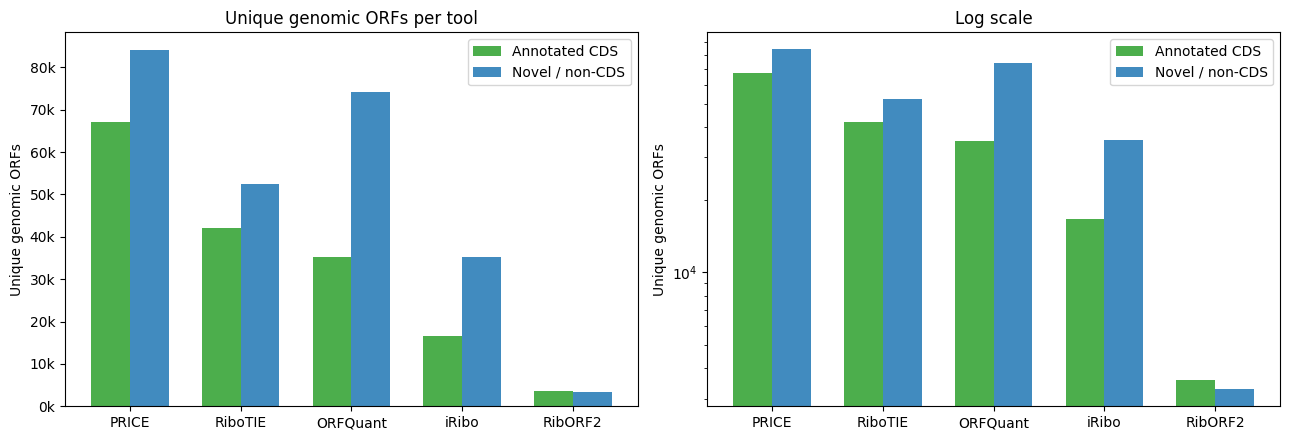

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(TOOL_ORDER))
w = 0.35

for ax, log in zip(axes, [False, True]):
    for i, cls in enumerate(CLS_ORDER):
        vals = totals[cls].values
        ax.bar(x + i * w - w / 2, vals, width=w,
               color=CLS_COLORS[cls], label=CLS_LABELS[cls], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(TOOL_ORDER, rotation=0)
    ax.set_ylabel("Unique genomic ORFs")
    ax.legend()
    if log:
        ax.set_yscale("log")
        ax.set_title("Log scale")
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
        ax.set_title("Unique genomic ORFs per tool")

plt.tight_layout()
plt.savefig("all_tool_call_space.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 2 — Per-sample unique novel ORFs

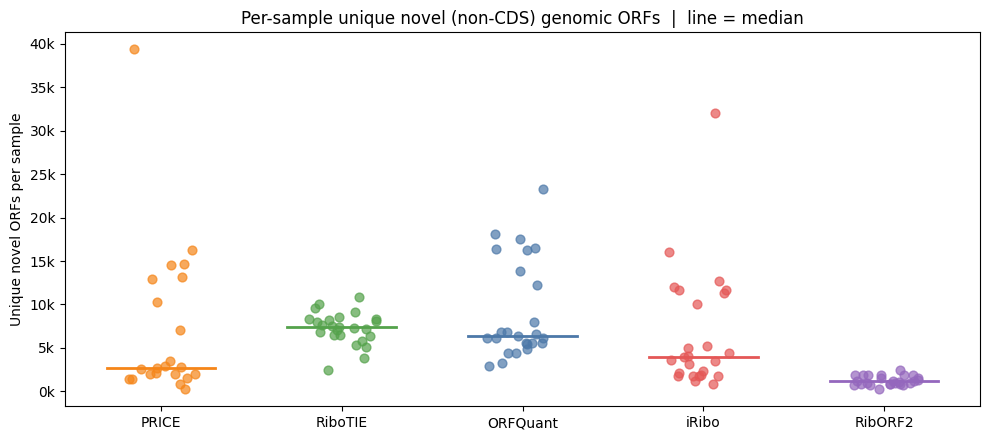

In [19]:
non_cds_ps = per_sample[per_sample["cls"] == "non_cds"].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))
rng = np.random.default_rng(42)
positions = {t: i for i, t in enumerate(TOOL_ORDER)}
for tool in TOOL_ORDER:
    vals = non_cds_ps.loc[non_cds_ps["source_tool"] == tool, "n"].values
    if len(vals) == 0:
        continue
    jitter = rng.uniform(-0.2, 0.2, len(vals))
    ax.scatter(positions[tool] + jitter, vals, color=TOOL_COLORS[tool],
               alpha=0.7, s=40, label=tool)
    ax.plot([positions[tool] - 0.3, positions[tool] + 0.3],
            [np.median(vals)] * 2, color=TOOL_COLORS[tool], lw=2)

ax.set_xticks(list(positions.values()))
ax.set_xticklabels(TOOL_ORDER)
ax.set_ylabel("Unique novel ORFs per sample")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_title("Per-sample unique novel (non-CDS) genomic ORFs  |  line = median")
plt.tight_layout()
plt.savefig("all_tool_noncds_per_sample.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 3 — Per-sample unique annotated ORFs and CDS recall

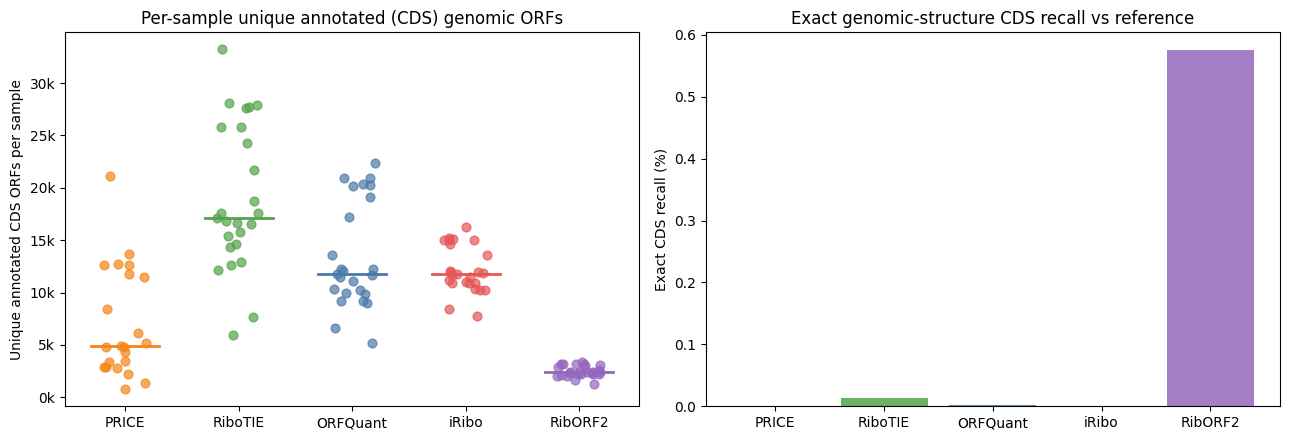

In [20]:
cds_ps = per_sample[per_sample["cls"] == "cds"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for tool in TOOL_ORDER:
    vals = cds_ps.loc[cds_ps["source_tool"] == tool, "n"].values
    if len(vals) == 0:
        ax.scatter([], [], color=TOOL_COLORS[tool], s=40, label=f"{tool} (no data)")
        continue
    jitter = rng.uniform(-0.2, 0.2, len(vals))
    ax.scatter(positions[tool] + jitter, vals,
               color=TOOL_COLORS[tool], alpha=0.7, s=40, label=tool)
    ax.plot([positions[tool] - 0.3, positions[tool] + 0.3],
            [np.median(vals)] * 2, color=TOOL_COLORS[tool], lw=2)
ax.set_xticks(list(positions.values()))
ax.set_xticklabels(TOOL_ORDER)
ax.set_ylabel("Unique annotated CDS ORFs per sample")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_title("Per-sample unique annotated (CDS) genomic ORFs")

ax = axes[1]
recall_filt = recall[recall["source_tool"] != "ANY"].set_index("source_tool").reindex(TOOL_ORDER).reset_index()
colors = [TOOL_COLORS.get(t, "grey") for t in recall_filt["source_tool"]]
ax.bar(recall_filt["source_tool"], recall_filt["exact_cds_recall_pct"], color=colors, alpha=0.85)
ax.set_ylabel("Exact CDS recall (%)")
ax.set_title("Exact genomic-structure CDS recall vs reference")

plt.tight_layout()
plt.savefig("all_tool_cds_recovery.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 4 — Start codon profile: CDS vs non-CDS by tool

Each unique genomic feature counted once.

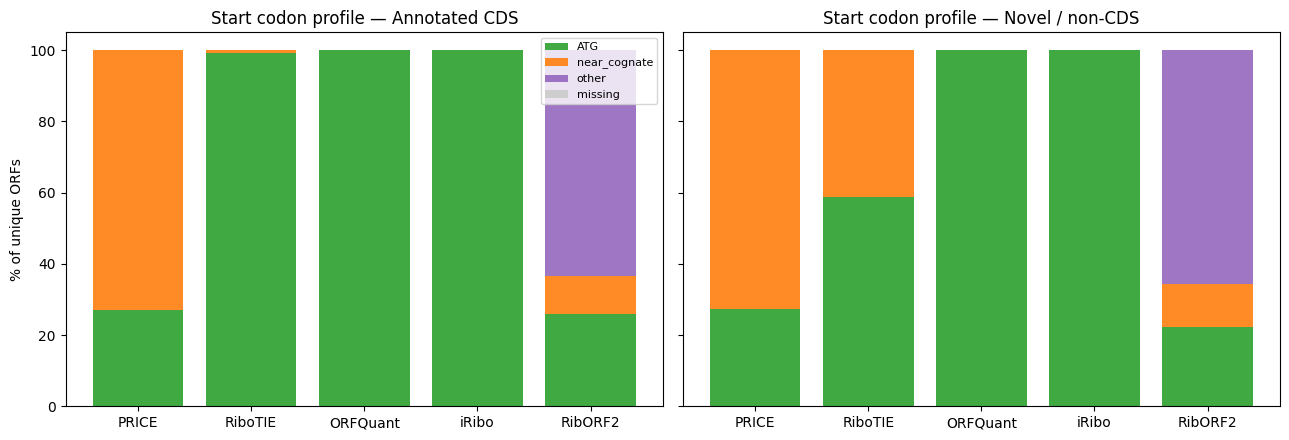

In [21]:
SC_ORDER  = ["ATG", "near_cognate", "other", "missing"]
SC_COLORS = {"ATG": "#2ca02c", "near_cognate": "#ff7f0e", "other": "#9467bd", "missing": "#cccccc"}

sc_pct = sc_counts.copy()
sc_pct["pct"] = (
    100 * sc_pct["n"] /
    sc_pct.groupby(["source_tool", "cls"])["n"].transform("sum")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
x = np.arange(len(TOOL_ORDER))

for ax, cls in zip(axes, CLS_ORDER):
    subset = (
        sc_pct[sc_pct.cls == cls]
        .pivot_table(index="source_tool", columns="start_codon_class",
                     values="pct", fill_value=0)
        .reindex(index=TOOL_ORDER)
        .reindex(columns=SC_ORDER, fill_value=0)
    )
    bottom = np.zeros(len(TOOL_ORDER))
    for sc_type in SC_ORDER:
        vals = subset[sc_type].values if sc_type in subset.columns else np.zeros(len(TOOL_ORDER))
        ax.bar(x, vals, bottom=bottom, color=SC_COLORS[sc_type], label=sc_type, alpha=0.9)
        bottom += vals
    ax.set_xticks(x); ax.set_xticklabels(TOOL_ORDER, rotation=0)
    ax.set_ylabel("% of unique ORFs" if cls == CLS_ORDER[0] else "")
    ax.set_ylim(0, 105)
    ax.set_title(f"Start codon profile — {CLS_LABELS[cls]}")
    if cls == CLS_ORDER[0]:
        ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("all_tool_start_codon_profile.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 5 — ORF size distribution by tool and class

Deduplicated by `feature_key`: each unique genomic structure contributes one data point.

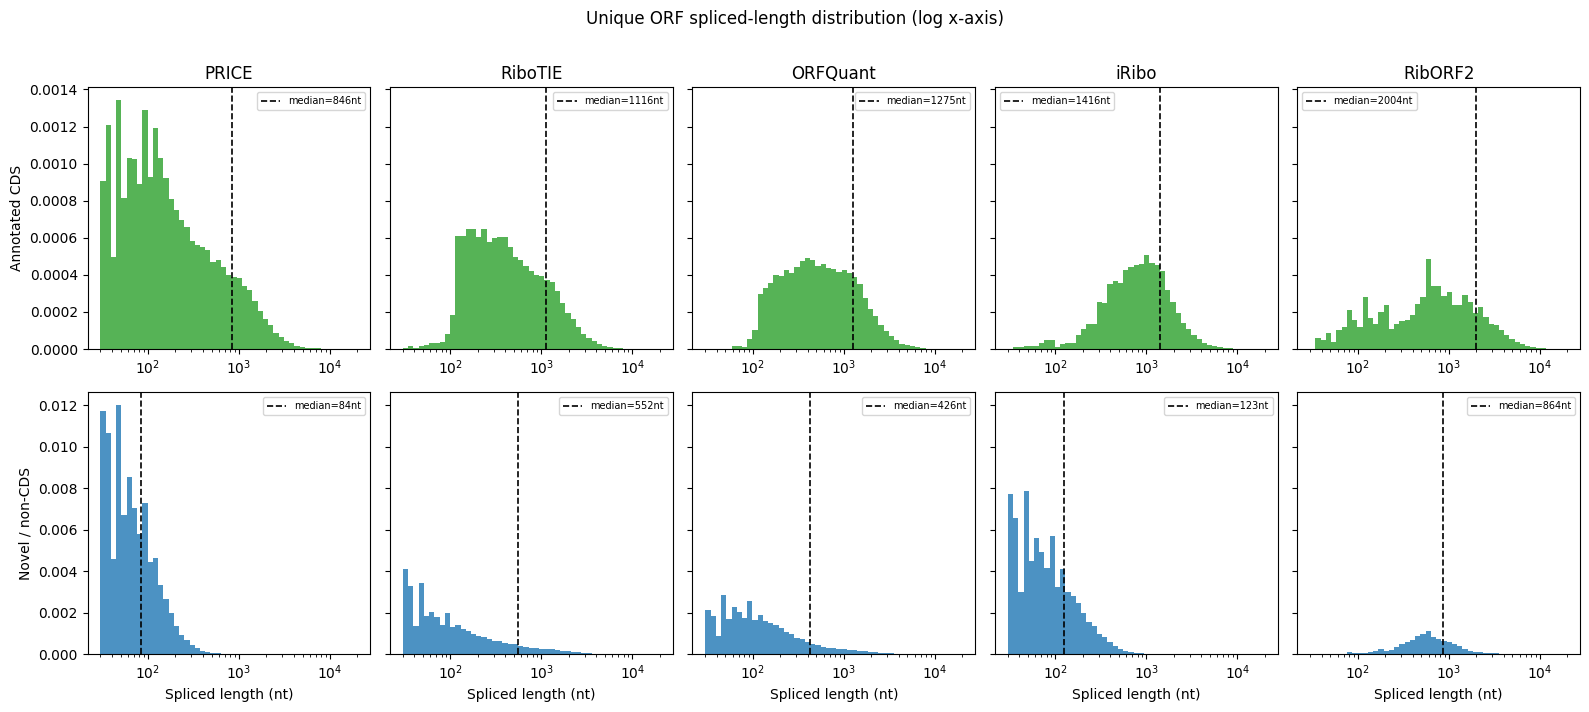

In [22]:
# One row per unique (tool, cls, feature_key) — takes MIN to collapse any duplicate rows
size_df = pd.read_sql(f"""
    SELECT source_tool, source_feature_class AS cls,
           MIN(spliced_length_nt) AS spliced_length_nt
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, source_feature_class, feature_key
""", con)

fig, axes = plt.subplots(2, len(TOOL_ORDER), figsize=(16, 7), sharey="row")
bins = np.logspace(np.log10(30), np.log10(20000), 50)

for col, tool in enumerate(TOOL_ORDER):
    for row, cls in enumerate(CLS_ORDER):
        ax = axes[row][col]
        vals = size_df.loc[
            (size_df["source_tool"] == tool) & (size_df["cls"] == cls),
            "spliced_length_nt"
        ].values
        if len(vals) == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.hist(vals, bins=bins, color=CLS_COLORS[cls], alpha=0.8, density=True)
            ax.axvline(np.median(vals), color="black", lw=1.2, ls="--",
                       label=f"median={np.median(vals):.0f}nt")
            ax.legend(fontsize=7)
        ax.set_xscale("log")
        if col == 0:
            ax.set_ylabel(CLS_LABELS[cls])
        if row == 0:
            ax.set_title(tool)
        if row == 1:
            ax.set_xlabel("Spliced length (nt)")

fig.suptitle("Unique ORF spliced-length distribution (log x-axis)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("all_tool_orf_size_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Plot 6 — Sample × tool coverage heatmap

Cell values are unique genomic ORFs called in that sample by that tool.

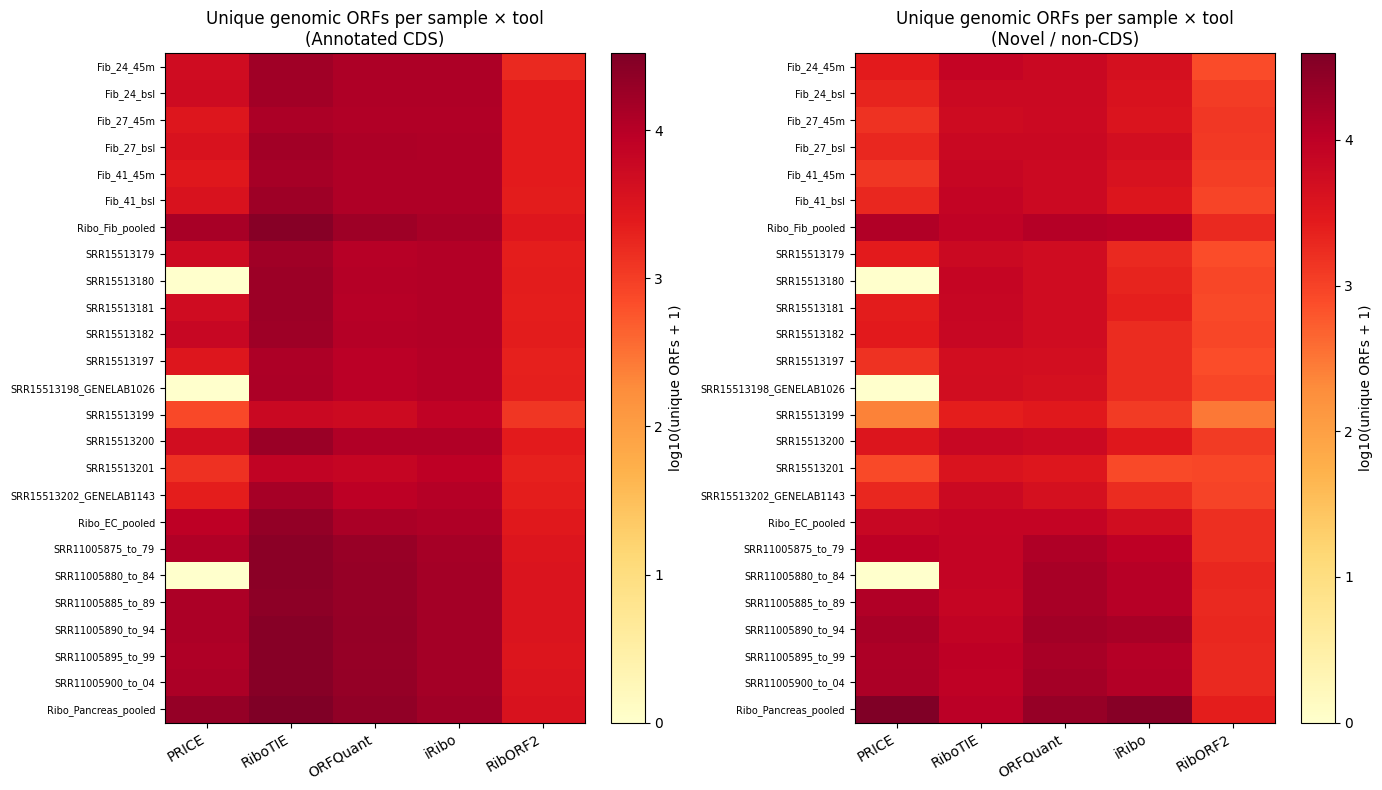

In [23]:
EXPECTED_SAMPLES = [
    "Fib_24_45m", "Fib_24_bsl", "Fib_27_45m", "Fib_27_bsl", "Fib_41_45m", "Fib_41_bsl",
    "Ribo_Fib_pooled",
    "SRR15513179", "SRR15513180", "SRR15513181", "SRR15513182",
    "SRR15513197", "SRR15513198_GENELAB1026", "SRR15513199",
    "SRR15513200", "SRR15513201", "SRR15513202_GENELAB1143",
    "Ribo_EC_pooled",
    "SRR11005875_to_79", "SRR11005880_to_84", "SRR11005885_to_89",
    "SRR11005890_to_94", "SRR11005895_to_99", "SRR11005900_to_04",
    "Ribo_Pancreas_pooled",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, cls in zip(axes, CLS_ORDER):
    mat = (
        per_sample[per_sample["cls"] == cls]
        .pivot_table(index="sample_id", columns="source_tool", values="n", fill_value=0)
        .reindex(index=EXPECTED_SAMPLES, columns=TOOL_ORDER, fill_value=0)
    )
    im = ax.imshow(np.log10(mat.values + 1), aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(TOOL_ORDER))); ax.set_xticklabels(TOOL_ORDER, rotation=30, ha="right")
    ax.set_yticks(range(len(EXPECTED_SAMPLES))); ax.set_yticklabels(EXPECTED_SAMPLES, fontsize=7)
    plt.colorbar(im, ax=ax, label="log10(unique ORFs + 1)")
    ax.set_title(f"Unique genomic ORFs per sample × tool\n({CLS_LABELS[cls]})")

plt.tight_layout()
plt.savefig("all_tool_sample_coverage_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## Summary table

In [24]:
summary_table = totals.copy()
summary_table["total"] = summary_table.sum(axis=1)
summary_table["cds_fraction"] = (
    summary_table.get("cds", 0) / summary_table["total"].replace(0, np.nan) * 100
).round(1)
display(summary_table)

cls,cds,non_cds,total,cds_fraction
source_tool,,,,
PRICE,67099.0,84070.0,151169.0,44.4
RiboTIE,42186.0,52451.0,94637.0,44.6
ORFQuant,35137.0,74085.0,109222.0,32.2
iRibo,16660.0,35342.0,52002.0,32.0
RibORF2,3572.0,3280.0,6852.0,52.1
